In [8]:
import pandas as pd 
import matplotlib.pyplot  as plt

In [5]:
df=pd.read_csv('placement1.csv')

In [6]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: title={'center': 'distrubution of marks'}, ylabel='Density'>

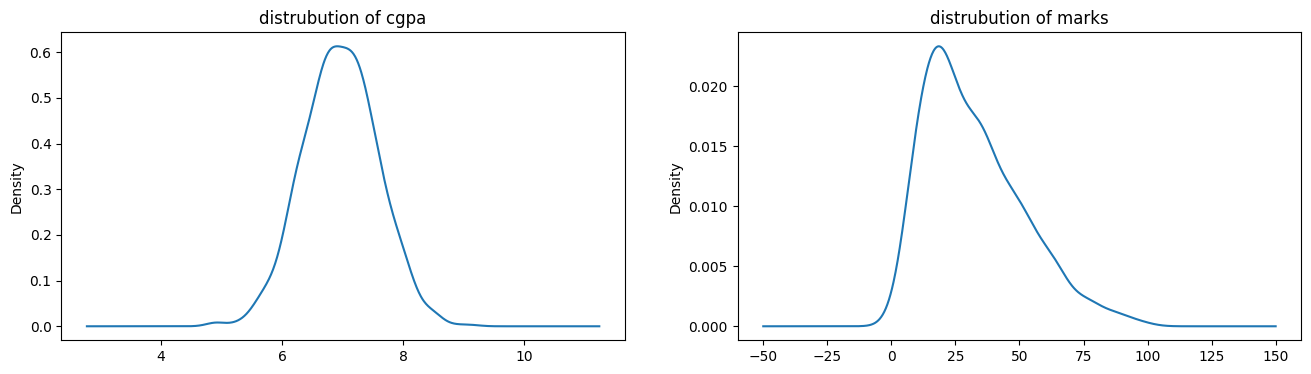

In [24]:
plt.figure(figsize=(16,4))
plt.subplot(121)
df['cgpa'].plot(kind='kde')
plt.title("distrubution of cgpa")
plt.subplot(122)
plt.title('distrubution of marks')
df['placement_exam_marks'].plot(kind='kde')

In [25]:
mean_cgpa=df['cgpa'].mean()
std_cgpa=df['cgpa'].std()
min_cgpa=df['cgpa'].min()
max_cgpa=df['cgpa'].max()

In [26]:
#finding the boundary values 
print('highest bounday is ',mean_cgpa+3*std_cgpa)
print('lowest bounday is ',mean_cgpa-3*std_cgpa)

highest bounday is  8.808933625397168
lowest bounday is  5.113546374602832


In [29]:
df[(df['cgpa']>8.8) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# trimming

In [33]:
new_df=df[(df['cgpa']<8.8) & (df['cgpa']>5.11)]

In [34]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


# calculating the z-score

In [43]:
df['z_score']=(df['cgpa']- mean_cgpa)/std_cgpa

In [44]:
df.sample(5)

,cgpa,placement_exam_marks,placed,z_score
149,6.81,58.0,0,-0.245560
106,6.59,22.0,0,-0.602762
623,7.35,14.0,1,0.631209
139,8.09,5.0,1,1.832706
890,7.73,30.0,0,1.248194


In [46]:
df[(df['z_score']>3) | (df['z_score']<-3)]

,cgpa,placement_exam_marks,placed,z_score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [47]:
new_df=df[(df['z_score']<3) & (df['z_score']>-3)]

In [48]:
new_df

,cgpa,placement_exam_marks,placed,z_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


# capping

In [63]:
upper_limit=(mean_cgpa+3*std_cgpa)
lower_limit=(mean_cgpa-3*std_cgpa)
import numpy as np

np.float64(5.113546374602832)

In [60]:
df['cgpa']=np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )  
)

In [61]:
df

,cgpa,placement_exam_marks,placed,z_score
0,7.190000,26.0,1,0.371425
1,7.460000,38.0,1,0.809810
2,7.540000,40.0,1,0.939701
3,6.420000,8.0,1,-0.878782
4,7.230000,17.0,0,0.436371
...,...,...,...,...
995,8.808934,44.0,1,3.099150
996,8.808934,65.0,1,3.505062
997,5.113546,34.0,0,-3.362960
998,8.620000,46.0,1,2.693239


In [62]:
df.describe()

,cgpa,placement_exam_marks,placed,z_score
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00
